<a href="https://colab.research.google.com/github/hsmu-jeongeun/medical-data-analysis/blob/main/05_machine_learning_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 의료 데이터 예시
- 유전자 발현량 데이터를 활용한 암 환자 군집화 및 분류

## 데이터 불러오기
- 위스콘신 유방암 데이터셋의 30개 feature를 30개의 유전자 발현량으로 가정

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

- 데이터 로드
  

In [2]:
data = load_breast_cancer()
feature_names = [f'Gene_{i+1}' for i in range(30)]
df = pd.DataFrame(data.data, columns=feature_names)
df['Target'] = data.target # 0: 암(Malignant), 1: 정상(Benign)

In [5]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
df.head(10)

,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,...,Gene_22,Gene_23,Gene_24,Gene_25,Gene_26,Gene_27,Gene_28,Gene_29,Gene_30,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


## 비지도 학습

### 차원 축소 및 시각화
  - 30차원 -> 2차원

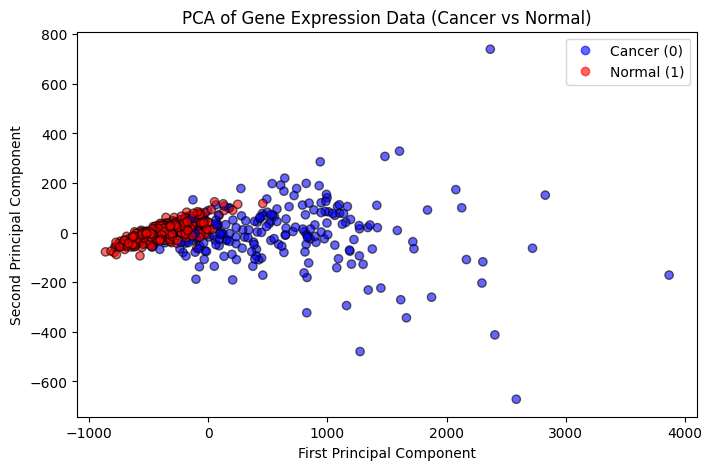

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Target'], cmap='bwr', alpha=0.6, edgecolor='k')
plt.legend(handles=scatter.legend_elements()[0], labels=['Cancer (0)', 'Normal (1)'])
plt.title("PCA of Gene Expression Data (Cancer vs Normal)")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

### K-means 군집화 및 시각화
- 물음표에 들어갈 내용을 채워보세요

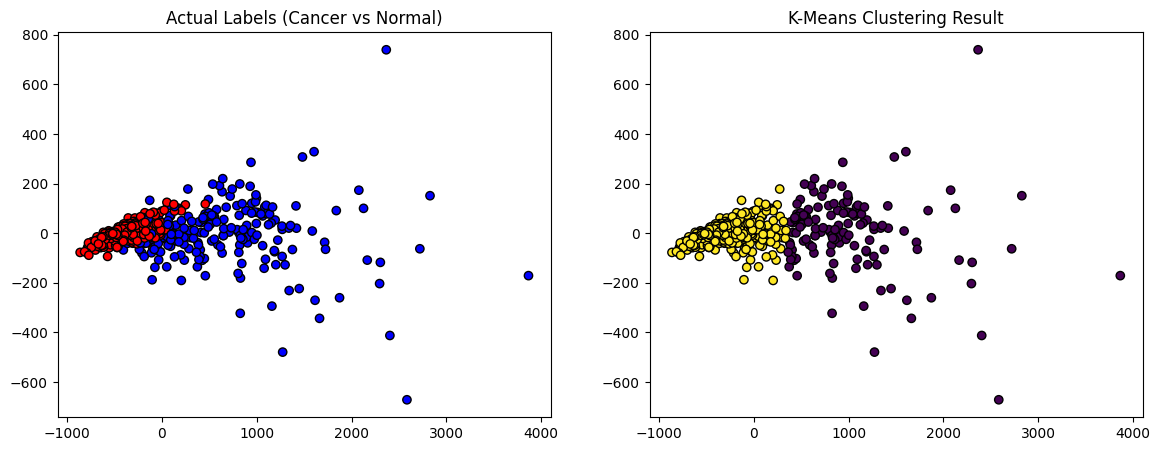

In [7]:
from sklearn.cluster import KMeans

# K-Means 모델 학습
kmeans = KMeans(n_clusters= ?, random_state=42)
cluster_labels = kmeans.fit_predict(df.drop('Target', axis=1))

# 실제 정답 vs K-Means 예측 결과 시각적 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실제 정답 산점도
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Target'], cmap='bwr', edgecolor='k')
axes[0].set_title('Actual Labels (Cancer vs Normal)')

# K-Means 군집 결과 산점도
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k')
axes[1].set_title('K-Means Clustering Result')
plt.show()

## 지도학습

### SVM과 Random Forest
- 물음표에 들어갈 내용을 채워보세요

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(df.drop('Target', axis=1), df['Target'], test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 선언 및 학습 (빈칸 채우기)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
rf_model = ?(random_state=42)

svm_model.?(X_train_scaled, y_train)
rf_model.?(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

--- SVM 혼동행렬 ---
 [[41  2]
 [ 3 68]]
--- RF 혼동행렬 ---
 [[40  3]
 [ 1 70]]


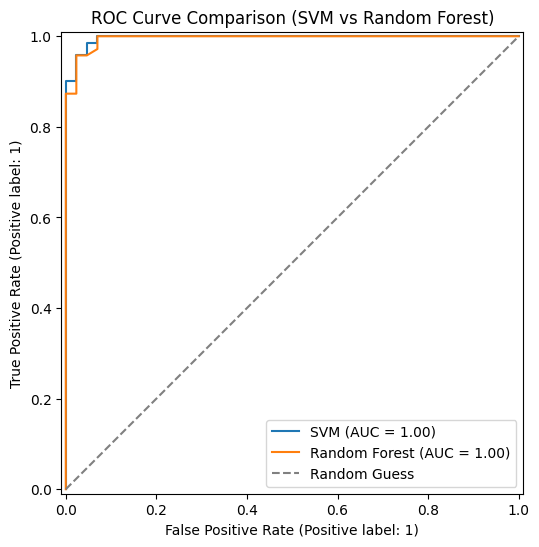

In [10]:
from sklearn.metrics import RocCurveDisplay, confusion_matrix

# 혼동행렬 출력
print("--- SVM 혼동행렬 ---\n", confusion_matrix(y_test, svm_model.predict(X_test_scaled)))
print("--- RF 혼동행렬 ---\n", confusion_matrix(y_test, rf_model.predict(X_test_scaled)))

# ROC Curve 시각화
plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(svm_model, X_test_scaled, y_test, ax=ax, name="SVM")
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test, ax=ax, name="Random Forest")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title("ROC Curve Comparison (SVM vs Random Forest)")
plt.legend()
plt.show()